# Retinal Vessel Segmentation: Train Multiple Models on Diverse Pairs

This notebook first selects the most diverse training pairs based on image and mask features, then trains a separate U-Net on each of these pairs. The best model (highest Dice on the test set) is identified for potential use.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import random

from PIL import Image
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.utils.data as data
import torchvision
import torchvision.transforms as T

import math
import cv2
from pathlib import Path

import skimage
from skimage.measure import label, regionprops
from skimage import morphology
import torchvision.models as models
from scipy.spatial.distance import pdist, squareform

print("All imports successful.")

All imports successful.


## Dataset Class

Loads images, LIOT features, and ground truth masks.

In [2]:
class ImageDataset(data.Dataset):
    def __init__(self, root, new_size=592, supervised=True):
        self.root = Path(root)
        self.supervised = supervised

        self.image_paths = sorted(self.root.rglob('*.tif*'))  # matches .tif or .tiff
        self.image_liot_eg_paths = sorted(self.root.rglob('*liot_eg*.npy'))
        if self.supervised:
            self.label_paths = sorted(list(self.root.rglob('*.gif')) + list(self.root.rglob('*.png')))

        # --- DEBUG PRINTS ---
        print(f"Dataset root: {root}")
        print(f"  Images found: {len(self.image_paths)}")
        if self.image_paths:
            print(f"  First 5 images: {[p.name for p in self.image_paths[:5]]}")
        print(f"  LIOT features found: {len(self.image_liot_eg_paths)}")
        if self.image_liot_eg_paths:
            print(f"  First 5 LIOT files: {[p.name for p in self.image_liot_eg_paths[:5]]}")
        if self.supervised:
            print(f"  Labels found: {len(self.label_paths)}")
            if self.label_paths:
                print(f"  First 5 labels: {[p.name for p in self.label_paths[:5]]}")
        # --------------------

        self.new_size = new_size
        self.imagesize = None

    def borders(self, original_size):
        """
        Compute padding for target size
        """
        H, W = original_size
        delta_h = max(self.new_size - H, 0)
        delta_w = max(self.new_size - W, 0)

        top    = delta_h // 2
        bottom = delta_h - top
        left   = delta_w // 2
        right  = delta_w - left

        return left, top, right, bottom

    def __getitem__(self, index):

        image_path = self.image_paths[index]
        image = Image.open(image_path)
        image_liot_eg_path = self.image_liot_eg_paths[index]
        image_liot_eg = np.load(image_liot_eg_path)

        if self.supervised:
            label_path = self.label_paths[index]
            label = Image.open(label_path)

        self.imagesize = np.shape(image)[0:2]

        transform = []
        transform.append(T.ToTensor())
        transform.append(T.Pad(
            self.borders(self.imagesize))
        )
        transform = T.Compose(transform)
        image = transform(image)
        image_liot_eg = transform(image_liot_eg.transpose(1, 2, 0))

        if self.supervised:
            label = transform(label)
            return image, image_liot_eg, label

        return image, image_liot_eg

    def __len__(self):
        return len(self.image_paths)

## Load Data

Dataset root: /home/mefeki/Bureau/work/drive_kaggle_prepared_data/test_data
  Images found: 20
  First 5 images: ['01_test.tif', '02_test.tif', '03_test.tif', '04_test.tif', '05_test.tif']
  LIOT features found: 20
  First 5 LIOT files: ['01_test_liot_eg.npy', '02_test_liot_eg.npy', '03_test_liot_eg.npy', '04_test_liot_eg.npy', '05_test_liot_eg.npy']
  Labels found: 20
  First 5 labels: ['01_test_mask.png', '02_test_mask.png', '03_test_mask.png', '04_test_mask.png', '05_test_mask.png']
Dataset root: /home/mefeki/Bureau/work/drive_kaggle_prepared_data/train_data_s
  Images found: 20
  First 5 images: ['21_training.tif', '22_training.tif', '23_training.tif', '24_training.tif', '25_training.tif']
  LIOT features found: 20
  First 5 LIOT files: ['21_training_liot_eg.npy', '22_training_liot_eg.npy', '23_training_liot_eg.npy', '24_training_liot_eg.npy', '25_training_liot_eg.npy']
  Labels found: 20
  First 5 labels: ['21_manual1.gif', '22_manual1.gif', '23_manual1.gif', '24_manual1.gif', '25

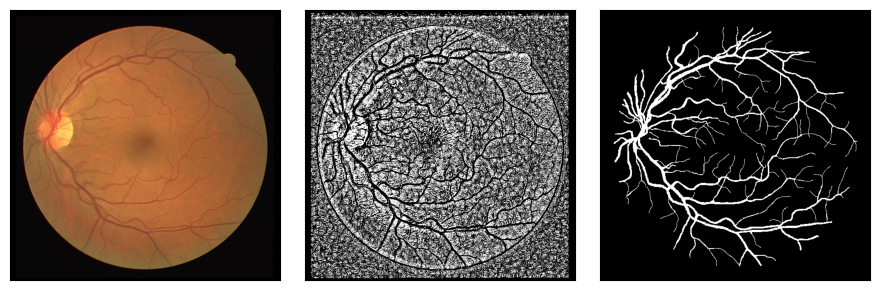

In [3]:
root = r"/home/mefeki/Bureau/work/drive_kaggle_prepared_data"
test_dataset = ImageDataset(root = os.path.join(root,'test_data'))
train_dataset_supervised = ImageDataset(root = os.path.join(root,'train_data_s'))

train_dataloader_supervised = data.DataLoader(train_dataset_supervised, shuffle = True, batch_size= 2)
test_dataloader = data.DataLoader(test_dataset, shuffle = False, batch_size = 1)

dataloaders = {'train supervised' : train_dataloader_supervised,  'test' : test_dataloader}
dataset_sizes = {'train supervised' : len(train_dataset_supervised),'test' : len(test_dataset)}
batch_sizes =  {'train supervised' : 2, 'test' : 1}
print("Dataset sizes: ", dataset_sizes)

it = iter(dataloaders['test'])
inputs, inputs_LIOT_eg, labels = next(it)
print("original size: ", test_dataset.imagesize)
original_size = T.CenterCrop(test_dataset.imagesize)
out_inputs = torchvision.utils.make_grid(inputs)
out_LIOT_eg_inputs = torchvision.utils.make_grid(inputs_LIOT_eg)
out_labels = torchvision.utils.make_grid(labels)

fig,axes = plt.subplots(1,3,figsize=(9,3))
axes[0].imshow(out_inputs.permute(1,2,0))
axes[0].set_xticks([])
axes[0].set_yticks([])
axes[1].imshow(out_LIOT_eg_inputs[0], cmap = "gray")
axes[1].set_xticks([])
axes[1].set_yticks([])
axes[2].imshow(out_labels.permute(1,2,0))
axes[2].set_xticks([])
axes[2].set_yticks([])
fig.tight_layout()
plt.show()

## U-Net Architecture

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# -------------------------
# Basic U-Net blocks
# -------------------------

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)


class Encoder(nn.Module):
    def __init__(self, in_ch=3, base_ch=32, depth=6):
        super().__init__()
        chs = [base_ch * (2 ** i) for i in range(depth)]
        self.blocks = nn.ModuleList()
        self.pools = nn.ModuleList()
        in_c = in_ch
        for c in chs:
            self.blocks.append(ConvBlock(in_c, c))
            self.pools.append(nn.MaxPool2d(2))
            in_c = c
        self.out_channels = chs

    def forward(self, x):
        feats = []
        for block, pool in zip(self.blocks, self.pools):
            x = block(x)
            feats.append(x)
            x = pool(x)
        return feats  # [P1, P2, ..., P6]


class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
        self.conv = ConvBlock(out_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        # align shapes if needed
        if x.size(-1) != skip.size(-1) or x.size(-2) != skip.size(-2):
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)


# -------------------------
# BiFPN block (bidirectional, weighted fusion)
# -------------------------

class SeparableConv2d(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, s=1, p=1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_ch, in_ch, k, s, p, groups=in_ch, bias=False)
        self.pointwise = nn.Conv2d(in_ch, out_ch, 1, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        x = self.bn(x)
        return self.act(x)


class BiFPN(nn.Module):
    def __init__(self, channels, num_layers=2, eps=1e-4):
        """
        channels   : list of bifpn_ch values, one per encoder level
        num_layers : number of bidirectional passes (recommend 2–3)
        """
        super().__init__()
        self.eps        = eps
        self.num_levels = len(channels)
        self.num_layers = num_layers

        # Use standard ConvBlock instead of SeparableConv2d
        # (more representational power with only 2 training images)
        self.convs_td = nn.ModuleList([ConvBlock(c, c) for c in channels])
        self.convs_bu = nn.ModuleList([ConvBlock(c, c) for c in channels])

        # top-down nodes fuse 2 inputs:  P[i] + upsample(td[i+1])
        self.w_td = nn.Parameter(torch.ones(num_layers, self.num_levels, 2))

        # bottom-up nodes fuse 3 inputs: P[i] + td[i] + pool(bu[i-1])  ← was 2
        self.w_bu = nn.Parameter(torch.ones(num_layers, self.num_levels, 3))

    def forward(self, feats):
        """feats: [P1, …, Pn]  low→high resolution, all projected to bifpn_ch"""
        P = feats  # keep original encoder features for the 3-input skip

        for l in range(self.num_layers):

            # ── Top-down pass ──────────────────────────────────────────────
            # td[-1] is the coarsest level; no fusion needed, copy as-is
            td = [None] * self.num_levels
            td[-1] = P[-1]

            for i in reversed(range(self.num_levels - 1)):
                w  = F.relu(self.w_td[l, i])
                w  = w / (torch.sum(w) + self.eps)
                up = F.interpolate(td[i + 1], size=P[i].shape[-2:],
                                   mode="bilinear", align_corners=False)
                td[i] = self.convs_td[i](w[0] * P[i] + w[1] * up)

            # ── Bottom-up pass ─────────────────────────────────────────────
            # bu[0] is the finest level; no fusion needed, copy td as-is
            bu = [None] * self.num_levels
            bu[0] = td[0]

            for i in range(1, self.num_levels):
                w    = F.relu(self.w_bu[l, i])
                w    = w / (torch.sum(w) + self.eps)

                down = F.max_pool2d(bu[i - 1], 2)

                # size guard: odd spatial dims can cause a 1-pixel mismatch
                if down.shape[-2:] != td[i].shape[-2:]:
                    down = F.interpolate(down, size=td[i].shape[-2:],
                                         mode="bilinear", align_corners=False)

                # 3-input fusion: original P[i]  +  top-down td[i]  +  pooled bu[i-1]
                bu[i] = self.convs_bu[i](w[0] * P[i] + w[1] * td[i] + w[2] * down)

            P = bu  # fused features become input for next BiFPN layer

        return P  # [P1', …, Pn']  all bifpn_ch channels


# -------------------------
# Full BIFPN-UNet model
# -------------------------

class BIFPNUNet(nn.Module):
    def __init__(self, in_ch=10, base_ch=32, depth=6,
                 num_bifpn_layers=1, out_ch=1, bifpn_ch=160):
        super().__init__()

        self.encoder = Encoder(in_ch=in_ch, base_ch=base_ch, depth=depth)

        # 1×1 projections: encoder channels -> bifpn_ch
        self.proj = nn.ModuleList([
            nn.Conv2d(c, bifpn_ch, kernel_size=1)
            for c in self.encoder.out_channels
        ])

        # BiFPN sees [bifpn_ch, ..., bifpn_ch]
        self.bifpn = BiFPN([bifpn_ch] * depth, num_layers=num_bifpn_layers)

        self.center = ConvBlock(bifpn_ch, bifpn_ch)

        self.up_blocks = nn.ModuleList()
        for _ in range(depth - 1):
            self.up_blocks.append(
                UpBlock(bifpn_ch, bifpn_ch, bifpn_ch)
            )

        self.final_conv = nn.Conv2d(bifpn_ch, out_ch, kernel_size=1)

    def forward(self, x):
        enc_feats = self.encoder(x)  # [P1,...,P6] with channels [32,64,128,256,512,1024]

        # IMPORTANT: project before BiFPN
        enc_feats = [proj(f) for proj, f in zip(self.proj, enc_feats)]
        # now all have channels = bifpn_ch

        fused_feats = self.bifpn(enc_feats)  # [P1',...,P6'] all bifpn_ch

        x = self.center(fused_feats[-1])

        for i, up in enumerate(self.up_blocks):
            skip = fused_feats[-2 - i]
            x = up(x, skip)

        x = self.final_conv(x)
        return x


## CLAHE Preprocessing

In [5]:
def clahe(inputs, clipLimit=4, tileGridSize=(8,8)):
    """
    Compute CLAHE for green channel of inputs.
    """
    inputs = inputs.to('cpu')
    clahe = cv2.createCLAHE(clipLimit=clipLimit, tileGridSize=tileGridSize)
    green_channel = np.uint8(255 * inputs[:,1,:,:])
    res = np.array([clahe.apply(i) for i in green_channel], dtype=float) / 255
    res = torch.tensor(res, dtype=torch.float).unsqueeze(1)
    return res.to(device)

## clDice (centerline Dice)

## Boundary-Loss (BZ_Loss)

In [6]:
class BZ_Loss(nn.Module):

    def __init__(self, config_loss=0, config_bz=0):
        super(BZ_Loss, self).__init__()
        self.Gx = torch.tensor(([-1,0,1],[-2,0,2],[-1,0,1]), dtype=torch.float)
        self.Gy = torch.tensor(([1,2,1],[0,0,0],[-1,-2,-1]), dtype=torch.float)
        self.RGB_to_GRAY = T.Grayscale()
        self.config_loss = config_loss
        self.config_bz   = config_bz

    def gaussian_kernel(self, kernel_size, sigma):
        ax = torch.linspace(-(kernel_size - 1) / 2., (kernel_size - 1) / 2., kernel_size)
        xx, yy = torch.meshgrid(ax, ax, indexing='xy')
        kernel = torch.exp(-0.5 * (torch.square(xx) + torch.square(yy)) / sigma ** 2)
        kernel = kernel / torch.sum(kernel)
        return kernel.unsqueeze(0).unsqueeze(0).to(device)

    def gaussian_filter(self, inputs, kernel_size, sigma):
        return F.conv2d(inputs, weight=self.gaussian_kernel(kernel_size, sigma), padding=kernel_size // 2)

    def hessian_square_norm(self, inputs, kernel_size=5, sigma=1):
        inputs = self.gaussian_filter(inputs, kernel_size, sigma)
        Gxxy = torch.stack((self.Gx, self.Gx, self.Gy)).unsqueeze(1).to(device)
        Gxyy = torch.stack((self.Gx, self.Gy, self.Gy)).unsqueeze(1).to(device)
        x = F.conv2d(inputs, weight=Gxxy, padding=1, groups=1)
        x = F.conv2d(x, weight=Gxyy, padding=1, groups=3)
        x = torch.square(x * (x > 0))
        x[:, 1, :, :] = 0
        x = torch.sum(x, dim=1, keepdim=True)
        return x

    def hessian_square_norm_binarized(self, inputs, kernel_size=5, sigma=1):
        x = self.hessian_square_norm(inputs)
        x = (x - torch.min(x)) / (torch.max(x) - torch.min(x))
        return torch.where((x > 1e-2), 1, 0).float()

    def hessian_supervised_denoised_BZ(self, inputs, labels, kernel_size=5, sigma=1):
        denoised_labels = self.gaussian_filter(labels, kernel_size, sigma)
        hessian_norm    = self.hessian_square_norm(inputs)
        return torch.mul(denoised_labels, hessian_norm).float()

    def gradient_square_norm(self, inputs, kernel_size=1, sigma=1):
        inputs = self.gaussian_filter(inputs, kernel_size, sigma)
        Gxy = torch.stack((self.Gx, self.Gy)).unsqueeze(1).to(device)
        x = F.conv2d(inputs, weight=Gxy, padding=1, groups=1)
        x = torch.square(x)
        x = torch.sum(x, dim=1, keepdim=True)
        return x

    def soft_skeletonize(self, x, num_iter=5):
        skel = x.clone()
        for _ in range(num_iter):
            eroded = -F.max_pool2d(-skel, kernel_size=3, stride=1, padding=1)
            skel   = F.relu(skel - eroded)
        return skel

    def cl_dice_loss(self, pred, label, num_iter=5, eps=1e-6):
        skel_pred  = self.soft_skeletonize(pred,  num_iter)
        skel_label = self.soft_skeletonize(label, num_iter)
        tprec = (torch.sum(skel_pred  * label) + eps) / (torch.sum(skel_pred)  + eps)
        tsens = (torch.sum(skel_label * pred)  + eps) / (torch.sum(skel_label) + eps)
        return 1.0 - 2.0 * (tprec * tsens) / (tprec + tsens + eps)

    def forward(self, outputs, labels, inputs, alpha, eps, beta, k_eps, supervised, cl_weight=0.5):
        match self.config_bz:
            case 0:
                BZ1 = torch.sum((torch.square(1 - outputs) + k_eps) * self.hessian_square_norm(inputs))
            case 1:
                BZ1 = torch.sum((torch.square(1 - outputs) + k_eps) * self.hessian_supervised_denoised_BZ(inputs, labels))

        BZ2 = beta * (torch.sum((eps * self.gradient_square_norm(1 - outputs) + torch.square(outputs) / (4 * eps))))
        BZ  = BZ1 + BZ2
        BCE = nn.BCELoss()
        CL  = self.cl_dice_loss(outputs, labels)

        match self.config_loss:
            case 0:
                loss = alpha * BZ + BCE(outputs, labels) + cl_weight * CL
            case 1:
                loss = alpha * BZ + 0.5 * BCE(outputs, labels) + 0.5 * BCE(outputs, self.hessian_square_norm_binarized(inputs)) + cl_weight * CL

        return loss

## Evaluation Metrics

In [7]:
def accuracy(preds, labels, eps=1e-6):
    preds = original_size(preds)
    labels = original_size(labels)
    corr = float(torch.sum(preds==labels))
    tensor_size = float(labels.size(0)*labels.size(1)*labels.size(2)*labels.size(3))
    return corr/(tensor_size+eps)

def sensitivity(preds, labels, eps=1e-6):
    preds = original_size(preds)
    labels = original_size(labels)
    TP = float(torch.sum((preds == 1)*(labels == 1)))
    FN = float(torch.sum((preds == 0)*(labels == 1)))
    return TP/(TP+FN+eps)

def specificity(preds, labels, eps=1e-6):
    preds = original_size(preds)
    labels = original_size(labels)
    TN = float(torch.sum((preds == 0)*(labels == 0)))
    FP = float(torch.sum((preds == 1)*(labels == 0)))
    return TN/(TN+FP+eps)

def precision(preds, labels, eps=1e-6):
    preds = original_size(preds)
    labels = original_size(labels)
    TP = float(torch.sum((preds == 1)*(labels == 1)))
    FP = float(torch.sum((preds == 1)*(labels == 0)))
    return TP/(TP+FP+eps)

def dice_coef(preds, labels, eps=1e-6):
    preds = original_size(preds)
    labels = original_size(labels)
    TP = float(torch.sum((preds == 1)*(labels == 1)))
    FP = float(torch.sum((preds == 1)*(labels == 0)))
    FN = float(torch.sum((preds == 0)*(labels == 1)))
    return 2*TP/(2*TP+FP+FN+eps)

## Post-processing: Remove Circles

In [8]:
def remove_circle(inputs, preds, kernel_size, threshold):
    # Handle RGBA by compositing on white background
    if inputs.shape[1] == 4:
        # Split RGB and alpha
        rgb = inputs[:, :3, :, :]
        alpha = inputs[:, 3:, :, :]
        # Composite on white background
        inputs = rgb * alpha + (1 - alpha)
    
    RGB_to_GRAY = T.Grayscale()
    mask = 1.*(RGB_to_GRAY(inputs) > threshold)
    
    p1 = -F.max_pool2d(-1.*mask, kernel_size=(kernel_size,1), stride=(1,1),
                       padding=(kernel_size//2,0))
    p2 = -F.max_pool2d(-1.*mask, kernel_size=(1,kernel_size), stride=(1,1),
                       padding=(0,kernel_size//2))
    mask = torch.min(p1, p2)
    return preds * mask

## Training Function

In [9]:
def train_model(model, criterion, optimizer, dataloader, num_epochs,
                alpha_factor=1.5, cl_weight=0.7):
    """
    Train model on a given dataloader for num_epochs.
    Returns the trained model and per-epoch loss history.
    """
    model.train()
    epoch_losses = []   # track mean loss per epoch

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 30)
        batch_losses = []
        for inputs, inputs_LIOT_vp, labels in dataloader:
            inputs = inputs.to(device)
            inputs_LIOT_vp = inputs_LIOT_vp.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs_LIOT_vp)
            outputs = torch.sigmoid(outputs)

            loss = criterion(outputs, labels, clahe(inputs),
                 alpha=alpha_factor / (inputs.shape[-1] ** 2),   # alpha_factor=1.5
                 eps=0.1, beta=0.5, k_eps=0,
                 supervised=True,
                 cl_weight=cl_weight)   # cl_weight=0.7

            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        epoch_losses.append(sum(batch_losses) / len(batch_losses))

    print('Training complete.')
    return model, epoch_losses


## Test Function

In [10]:
def test_model(model, threshold, BZ=True, display_results=False):
    """
    Evaluate model on test set and return average dice coefficient.
    """
    model.eval()
    total_dice = 0.0
    with torch.no_grad():
        for inputs, inputs_LIOT_vp, labels in dataloaders['test']:
            inputs = inputs.to(device)
            inputs_LIOT_vp = inputs_LIOT_vp.to(device)
            labels = labels.to(device)

            outputs = model(inputs_LIOT_vp)
            outputs = torch.sigmoid(outputs)
            preds = outputs > threshold

            if BZ:
                preds = remove_circle(inputs, preds, 7, 0.1)

            total_dice += dice_coef(preds, labels)

            if display_results:
                grid = torchvision.utils.make_grid([labels[0], preds[0]]).cpu()
                plt.figure(figsize=(8, 8))
                plt.imshow(grid.permute(1,2,0))
                plt.xticks([])
                plt.yticks([])
                plt.show()
    return total_dice / dataset_sizes['test']

## Feature Extraction for Diversity Sampling

In [11]:
def extract_image_features(images, model, transform, device):
    """
    Extract features from a list of PIL images using a pretrained CNN.
    Returns a numpy array of shape (len(images), feature_dim).
    """
    model.eval()
    features = []
    with torch.no_grad():
        for img in images:
            img_t = transform(img).unsqueeze(0).to(device)
            feat = model(img_t).cpu().numpy().flatten()
            features.append(feat)
    return np.array(features)

def extract_mask_features(masks):
    """
    For each binary mask (PIL image) compute:
        - area (normalized by image size)
        - centroid (x, y) normalized by width/height
        - number of connected components
        - aspect ratio (width/height of bounding box)
    Returns a numpy array of shape (len(masks), 5).
    """
    stats = []
    for mask in masks:
        mask_np = np.array(mask) / 255  # convert to 0/1
        mask_np = (mask_np > 0.5).astype(np.uint8)
        labeled = label(mask_np, connectivity=2)
        num_components = labeled.max()
        if num_components == 0:
            stats.append([0.0, 0.5, 0.5, 0.0, 1.0])
            continue
        props = regionprops(labeled)
        largest = max(props, key=lambda p: p.area)
        area_norm = largest.area / (mask_np.shape[0] * mask_np.shape[1])
        cy, cx = largest.centroid
        centroid_norm = (cx / mask_np.shape[1], cy / mask_np.shape[0])
        minr, minc, maxr, maxc = largest.bbox
        bbox_h = maxr - minr
        bbox_w = maxc - minc
        aspect = bbox_w / bbox_h if bbox_h > 0 else 1.0
        stats.append([area_norm, centroid_norm[0], centroid_norm[1],
                      num_components, aspect])
    return np.array(stats)

## ResNet Feature Extraction & Most-Different Pair Selection

A pretrained ResNet50 extracts a 2048-d feature vector for every training image. The pairwise Euclidean distances between all feature vectors are computed, and the single pair of images that are furthest apart in feature space is selected.

In [12]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_root = os.path.join(root, 'train_data_s')
train_dataset_full = ImageDataset(root=train_root, supervised=True)

# Load all training images (original size, RGB)
image_paths = train_dataset_full.image_paths

print("Loading images...")
images = []
for p in image_paths:
    img = Image.open(p).convert('RGB')
    images.append(img)

# ── ResNet50 feature extractor ─────────────────────────────────────────────
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
resnet = torch.nn.Sequential(*list(resnet.children())[:-1])  # remove classifier head → (B, 2048, 1, 1)
resnet.to(device)

resnet_transform = T.Compose([
    T.Resize(224),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Extract feature vectors for every training image
print("Extracting image features with ResNet50...")
img_features = extract_image_features(images, resnet, resnet_transform, device)
print("Image features shape:", img_features.shape)  # (N, 2048)

# ── Pairwise Euclidean distances ───────────────────────────────────────────
print("Computing pairwise Euclidean distances...")
dist_matrix = squareform(pdist(img_features, metric='euclidean'))

# Mask diagonal (self-distance = 0) so argmax picks an off-diagonal pair
dist_matrix_masked = dist_matrix.copy()
np.fill_diagonal(dist_matrix_masked, -np.inf)

# Find the single pair (i, j) with the largest feature-space distance
flat_idx = np.argmax(dist_matrix_masked)
idx_i, idx_j = np.unravel_index(flat_idx, dist_matrix_masked.shape)
max_dist = dist_matrix[idx_i, idx_j]

print(f"Most different pair: image {idx_i} and image {idx_j}  "
      f"(ResNet L2 distance = {max_dist:.4f})")
print(f"  Image A: {image_paths[idx_i].name}")
print(f"  Image B: {image_paths[idx_j].name}")


Using device: cuda:0
Dataset root: /home/mefeki/Bureau/work/drive_kaggle_prepared_data/train_data_s
  Images found: 20
  First 5 images: ['21_training.tif', '22_training.tif', '23_training.tif', '24_training.tif', '25_training.tif']
  LIOT features found: 20
  First 5 LIOT files: ['21_training_liot_eg.npy', '22_training_liot_eg.npy', '23_training_liot_eg.npy', '24_training_liot_eg.npy', '25_training_liot_eg.npy']
  Labels found: 20
  First 5 labels: ['21_manual1.gif', '22_manual1.gif', '23_manual1.gif', '24_manual1.gif', '25_manual1.gif']
Loading images...
Extracting image features with ResNet50...
Image features shape: (20, 2048)
Computing pairwise Euclidean distances...
Most different pair: image 2 and image 15  (ResNet L2 distance = 17.0325)
  Image A: 23_training.tif
  Image B: 36_training.tif


## Train U-Net on the Most Diverse Pair

A single U-Net is trained from scratch on the two images identified as the most different by ResNet feature distance.

In [13]:
# Training hyperparameters
EPOCHS = 150
BATCH_SIZE = 1  # process one image at a time (dataset has 2 images)

# Create a dataset containing only the most-different pair
pair_dataset = torch.utils.data.Subset(train_dataset_full, [idx_i, idx_j])
pair_dataloader = data.DataLoader(pair_dataset, shuffle=True, batch_size=BATCH_SIZE)

print(f"\n=== Training U-Net on the most diverse pair: images {idx_i} and {idx_j} ===")

# Initialise model, loss, optimiser
model = BIFPNUNet(
    in_ch=10,
    base_ch=64,
    depth=4,
    num_bifpn_layers=2,
    out_ch=1,
    bifpn_ch=128
).to(device)

criterion = BZ_Loss(config_loss=0, config_bz=1)
optimizer = optim.Adam(model.parameters(), lr=1e-3, betas=(0.9, 0.999), eps=1e-07)

# Train
# alpha_factor=1.5 → alpha = 1.5 / spatial_size²   |   cl_weight=0.7
model, training_losses = train_model(
    model, criterion, optimizer, pair_dataloader,
    num_epochs=EPOCHS, alpha_factor=1.5, cl_weight=0.7
)

# Evaluate on test set
dice = test_model(model, threshold=0.1, BZ=True, display_results=False)
print(f"\nDice on test set: {dice:.4f}")

best_model_state = model.state_dict().copy()
best_index = (idx_i, idx_j)
best_dice = dice



=== Training U-Net on the most diverse pair: images 2 and 15 ===
Epoch 1/150
------------------------------
Epoch 2/150
------------------------------
Epoch 3/150
------------------------------
Epoch 4/150
------------------------------
Epoch 5/150
------------------------------
Epoch 6/150
------------------------------
Epoch 7/150
------------------------------
Epoch 8/150
------------------------------
Epoch 9/150
------------------------------
Epoch 10/150
------------------------------
Epoch 11/150
------------------------------
Epoch 12/150
------------------------------
Epoch 13/150
------------------------------
Epoch 14/150
------------------------------
Epoch 15/150
------------------------------
Epoch 16/150
------------------------------
Epoch 17/150
------------------------------
Epoch 18/150
------------------------------
Epoch 19/150
------------------------------
Epoch 20/150
------------------------------
Epoch 21/150
------------------------------
Epoch 22/150
------

In [ ]:
# ═══════════════════════════════════════════════════════════════════
#  Training diagnostics: loss curve + hyperparameter summary
# ═══════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Hyperparameters used in this run ────────────────────────────────
hparams = {
    "Model"            : "BiFPN-UNet",
    "in_ch"            : 10,
    "base_ch"          : 64,
    "depth"            : 4,
    "num_bifpn_layers" : 2,
    "bifpn_ch"         : 128,
    "Epochs"           : EPOCHS,
    "Batch size"       : BATCH_SIZE,
    "Optimizer"        : "Adam",
    "Learning rate"    : "1e-3",
    "Adam betas"       : "(0.9, 0.999)",
    "Adam eps"         : "1e-07",
    "Loss"             : "BZ_Loss (config_loss=0, config_bz=1)",
    "alpha_factor"     : 1.5,
    "alpha (formula)"  : "1.5 / spatial_size²",
    "cl_weight"        : 0.7,
    "eps"              : 0.1,
    "beta"             : 0.5,
    "k_eps"            : 0,
    "Test threshold"   : 0.1,
    "Train pair"       : f"images {idx_i} & {idx_j}",
}

# ── Figure layout ────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 6))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1.6, 1], figure=fig)

# ── Left: loss curve ────────────────────────────────────────────────
ax_loss = fig.add_subplot(gs[0])
epochs  = np.arange(1, len(training_losses) + 1)

ax_loss.plot(epochs, training_losses, color="#2563EB", linewidth=1.8,
             label="Train loss (mean / epoch)")

# rolling average (window = 10) for trend
if len(training_losses) >= 10:
    window  = 10
    smooth  = np.convolve(training_losses, np.ones(window) / window, mode="valid")
    ax_loss.plot(np.arange(window, len(training_losses) + 1), smooth,
                 color="#DC2626", linewidth=2, linestyle="--",
                 label=f"Rolling avg (w={window})")

ax_loss.set_xlabel("Epoch", fontsize=12)
ax_loss.set_ylabel("Loss", fontsize=12)
ax_loss.set_title("Training Loss Curve", fontsize=13, fontweight="bold")
ax_loss.legend(fontsize=10)
ax_loss.grid(True, alpha=0.3)
ax_loss.set_xlim(1, len(training_losses))

# Annotate min loss
min_val = min(training_losses)
min_ep  = training_losses.index(min_val) + 1
ax_loss.annotate(f"min={min_val:.4f}\n(ep {min_ep})",
                 xy=(min_ep, min_val),
                 xytext=(min_ep + max(1, len(training_losses)//15), min_val * 1.05),
                 arrowprops=dict(arrowstyle="->", color="gray"),
                 fontsize=9, color="#15803D")

# ── Right: hyperparameter table ──────────────────────────────────────
ax_hp = fig.add_subplot(gs[1])
ax_hp.axis("off")

rows = [[k, str(v)] for k, v in hparams.items()]
col_labels = ["Hyperparameter", "Value"]

tbl = ax_hp.table(
    cellText=rows,
    colLabels=col_labels,
    loc="center",
    cellLoc="left",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.35)

# Style header
for c in range(2):
    tbl[(0, c)].set_facecolor("#1E40AF")
    tbl[(0, c)].set_text_props(color="white", fontweight="bold")

# Highlight key rows (alpha_factor, cl_weight)
highlight_keys = {"alpha_factor", "cl_weight"}
for r, (k, _) in enumerate(rows, start=1):
    if k in highlight_keys:
        for c in range(2):
            tbl[(r, c)].set_facecolor("#FEF9C3")
            tbl[(r, c)].set_text_props(fontweight="bold")

ax_hp.set_title("Hyperparameter Summary", fontsize=13, fontweight="bold", pad=12)

fig.suptitle(
    f"BiFPN-UNet  |  α-factor=1.5  |  cl_weight=0.7  |  "
    f"Final loss={training_losses[-1]:.4f}  |  Dice={best_dice:.4f}",
    fontsize=11, y=1.01
)

fig.tight_layout()
plt.savefig("training_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to training_diagnostics.png")


## Grid search for alpha and Cl_weight

 Run | alpha_factor | cl_weight |     Dice | Accuracy
--------------------------------------------------------
   1 |         0.10 |      0.10 |   0.7534 |   0.9557 ◄ BEST
   2 |         0.10 |      0.30 |   0.6997 |   0.9378
   3 |         0.10 |      0.50 |   0.7344 |   0.9478
   4 |         0.10 |      0.70 |   0.7188 |   0.9443
   5 |         0.10 |      1.00 |   0.6600 |   0.9286
   6 |         0.10 |      1.50 |   0.7426 |   0.9571
   7 |         0.30 |      0.10 |   0.7441 |   0.9573
   8 |         0.30 |      0.30 |   0.7207 |   0.9445
   9 |         0.30 |      0.50 |   0.7003 |   0.9347
  10 |         0.30 |      0.70 |   0.7514 |   0.9546
  11 |         0.30 |      1.00 |   0.7165 |   0.9444
  12 |         0.30 |      1.50 |   0.7276 |   0.9537
  13 |         0.50 |      0.10 |   0.6914 |   0.9552
  14 |         0.50 |      0.30 |   0.6907 |   0.9351
  15 |         0.50 |      0.50 |   0.7045 |   0.9382
  16 |         0.50 |      0.70 |   0.7356 |   0.9475
  17 |         0.5

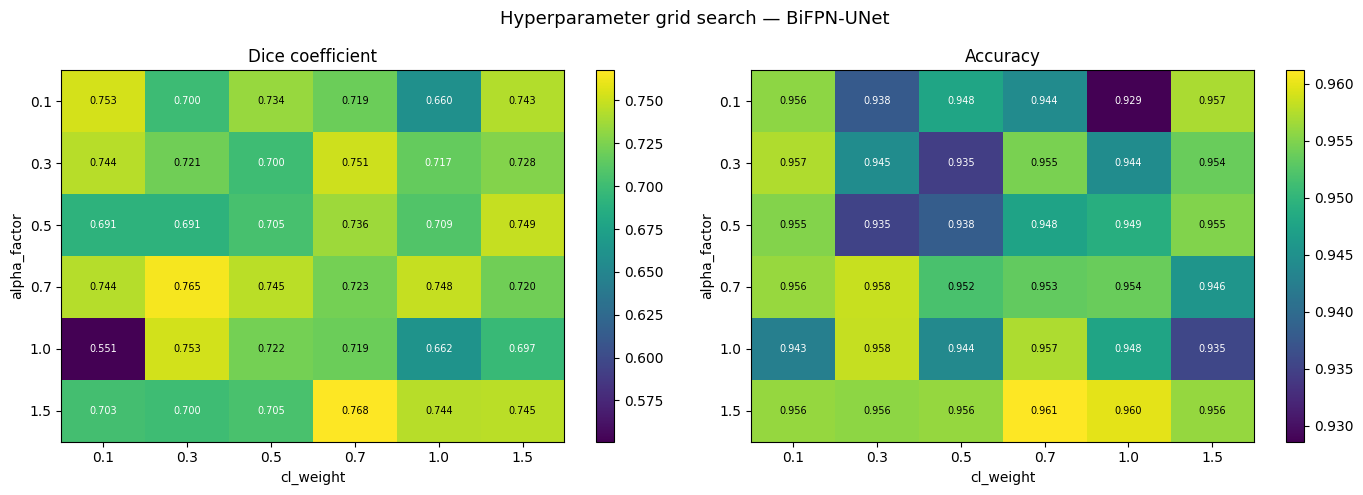

Heat-map saved to models/gridsearch_heatmap.png


In [14]:
"""
Grid search over alpha_factor (the numerator in alpha = factor / size²)
and cl_weight, maximising Dice and Accuracy on the test set.

Paste this as a new cell AFTER cell 26 (the main training cell).
All functions/variables from the notebook must already be defined.
"""

import itertools
import copy
import pandas as pd

# ─────────────────────────────────────────────
#  Search grid
# ─────────────────────────────────────────────
ALPHA_FACTORS = [0.1, 0.3, 0.5, 0.7, 1.0, 1.5]   # α = factor / size²
CL_WEIGHTS    = [0.1, 0.3, 0.5, 0.7, 1.0, 1.5]   # weight on CL-Dice term

SEARCH_EPOCHS   = 150      # same as your main run
THRESHOLD       = 0.50     # same as your best threshold
SEED            = 42

# ─────────────────────────────────────────────
#  Helper: train + evaluate one config
# ─────────────────────────────────────────────
def run_config(alpha_factor, cl_weight, pair_dataloader, idx_i, idx_j,
               epochs=SEARCH_EPOCHS, threshold=THRESHOLD):

    torch.manual_seed(SEED)
    random.seed(SEED)
    np.random.seed(SEED)

    m = BIFPNUNet(
        in_ch=10, base_ch=64, depth=4,
        num_bifpn_layers=2, out_ch=1, bifpn_ch=128
    ).to(device)

    crit = BZ_Loss(config_loss=0, config_bz=1)
    opt  = optim.Adam(m.parameters(), lr=1e-3, betas=(0.9, 0.999), eps=1e-07)

    # ── train ──────────────────────────────────────────────────────────
    m.train()
    for epoch in range(epochs):
        for inputs, inputs_LIOT_vp, labels in pair_dataloader:
            inputs         = inputs.to(device)
            inputs_LIOT_vp = inputs_LIOT_vp.to(device)
            labels         = labels.to(device)

            opt.zero_grad()
            outputs = torch.sigmoid(m(inputs_LIOT_vp))

            loss = crit(
                outputs, labels, clahe(inputs),
                alpha     = alpha_factor / (inputs.shape[-1] ** 2),
                eps       = 0.1,
                beta      = 0.5,
                k_eps     = 0,
                supervised= True,
                cl_weight = cl_weight,
            )
            loss.backward()
            opt.step()

    # ── evaluate ───────────────────────────────────────────────────────
    m.eval()
    total_dice = 0.0
    total_acc  = 0.0
    n = 0
    with torch.no_grad():
        for inputs, inputs_LIOT_vp, labels in dataloaders['test']:
            inputs         = inputs.to(device)
            inputs_LIOT_vp = inputs_LIOT_vp.to(device)
            labels         = labels.to(device)

            outputs = torch.sigmoid(m(inputs_LIOT_vp))
            preds   = outputs > threshold
            preds   = remove_circle(inputs, preds, 7, 0.1)

            total_dice += dice_coef(preds, labels)
            total_acc  += accuracy(preds, labels)
            n += 1

    avg_dice = total_dice / n
    avg_acc  = total_acc  / n
    return avg_dice, avg_acc, m.state_dict()

# ─────────────────────────────────────────────
#  Grid search loop
# ─────────────────────────────────────────────
results      = []
best_dice    = -1.0
best_state   = None
best_params  = {}

total_runs = len(ALPHA_FACTORS) * len(CL_WEIGHTS)
run_idx    = 0

print(f"{'Run':>4} | {'alpha_factor':>12} | {'cl_weight':>9} | {'Dice':>8} | {'Accuracy':>8}")
print("-" * 56)

for alpha_factor, cl_weight in itertools.product(ALPHA_FACTORS, CL_WEIGHTS):
    run_idx += 1
    dice, acc, state = run_config(
        alpha_factor, cl_weight, pair_dataloader, idx_i, idx_j
    )

    results.append({
        "alpha_factor": alpha_factor,
        "cl_weight"   : cl_weight,
        "Dice"        : round(dice, 4),
        "Accuracy"    : round(acc, 4),
    })

    marker = " ◄ BEST" if dice > best_dice else ""
    print(f"{run_idx:>4} | {alpha_factor:>12.2f} | {cl_weight:>9.2f} | {dice:>8.4f} | {acc:>8.4f}{marker}")

    if dice > best_dice:
        best_dice   = dice
        best_state  = copy.deepcopy(state)
        best_params = {"alpha_factor": alpha_factor, "cl_weight": cl_weight}

# ─────────────────────────────────────────────
#  Summary
# ─────────────────────────────────────────────
df = pd.DataFrame(results).sort_values("Dice", ascending=False)

print("\n" + "=" * 56)
print("TOP 5 configurations by Dice:")
print(df.head(5).to_string(index=False))

print(f"\n✓ Best: alpha_factor={best_params['alpha_factor']}, "
      f"cl_weight={best_params['cl_weight']}  →  Dice={best_dice:.4f}")

# ─────────────────────────────────────────────
#  Save best model
# ─────────────────────────────────────────────
import os
os.makedirs("models", exist_ok=True)
torch.save(best_state,
           f"models/best_model_gs_a{best_params['alpha_factor']}_cl{best_params['cl_weight']}.pth")
print("Best model saved.")

# ─────────────────────────────────────────────
#  Heat-map (optional, requires matplotlib)
# ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

pivot_dice = df.pivot(index="alpha_factor", columns="cl_weight", values="Dice")
pivot_acc  = df.pivot(index="alpha_factor", columns="cl_weight", values="Accuracy")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, pivot, title in zip(axes,
                             [pivot_dice, pivot_acc],
                             ["Dice coefficient", "Accuracy"]):
    im = ax.imshow(pivot.values, cmap="viridis", aspect="auto")
    ax.set_xticks(range(len(CL_WEIGHTS)));  ax.set_xticklabels(CL_WEIGHTS)
    ax.set_yticks(range(len(ALPHA_FACTORS))); ax.set_yticklabels(ALPHA_FACTORS)
    ax.set_xlabel("cl_weight");  ax.set_ylabel("alpha_factor")
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
    # annotate cells
    for r in range(pivot.values.shape[0]):
        for c in range(pivot.values.shape[1]):
            ax.text(c, r, f"{pivot.values[r,c]:.3f}",
                    ha="center", va="center", fontsize=7,
                    color="white" if pivot.values[r,c] < pivot.values.mean() else "black")

fig.suptitle("Hyperparameter grid search — BiFPN-UNet", fontsize=13)
fig.tight_layout()
plt.savefig("models/gridsearch_heatmap.png", dpi=150)
plt.show()
print("Heat-map saved to models/gridsearch_heatmap.png")


## Save the Best Model

We save the state dict of the best performing model for future use.

In [15]:
if best_model_state is not None:
    torch.save(best_model_state, 'models/best_model_BIFPN_3.pth')
    print(f"Best model saved as 'best_model_BIFPN_3.pth' "
          f"(trained on pair {best_index}, Dice = {best_dice:.4f})")
else:
    print("No model was trained.")


Best model saved as 'best_model_BIFPN_3.pth' (trained on pair (np.int64(2), np.int64(15)), Dice = 0.7676)


## (Optional) Visualize the Best Model's Predictions

You can run this cell to see some example segmentations from the best model.

In [16]:
model.eval()
with torch.no_grad():
    inputs, liot, labels = next(iter(pair_dataloader))
    out = torch.sigmoid(model(liot.to(device)))
    print("Pred min/max/mean:", out.min().item(), out.max().item(), out.mean().item())
    print("Label mean (vessel fraction):", labels.mean().item())


Pred min/max/mean: 0.00016578898066654801 1.0 0.12536324560642242
Label mean (vessel fraction): 0.10238997638225555


In [17]:
model.eval()
with torch.no_grad():
    for thresh in [ 0.10, 0.15, 0.20, 0.5, 0.6,0.7]:
        dice = test_model(model, threshold=thresh, BZ=True, display_results=False)
        print(f"Threshold {thresh:.2f} → Dice = {dice:.4f}")

Threshold 0.10 → Dice = 0.5937
Threshold 0.15 → Dice = 0.6279
Threshold 0.20 → Dice = 0.6542
Threshold 0.50 → Dice = 0.6952
Threshold 0.60 → Dice = 0.6920
Threshold 0.70 → Dice = 0.6864


Test set results:
Accuracy:  0.9501
Sensitivity: 0.6560
Dice:      0.6952


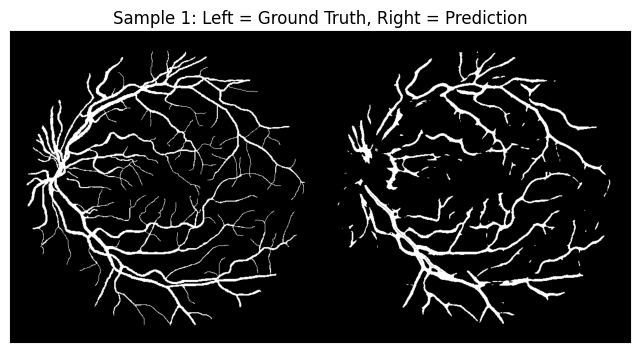

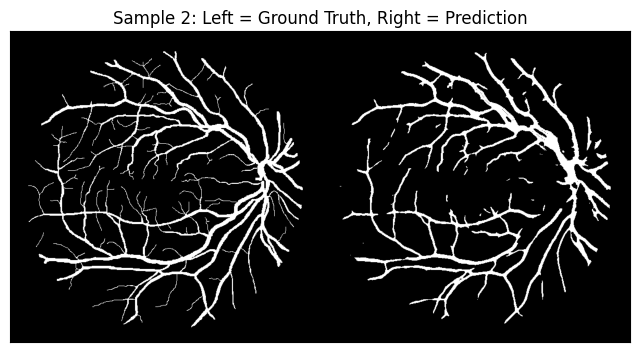

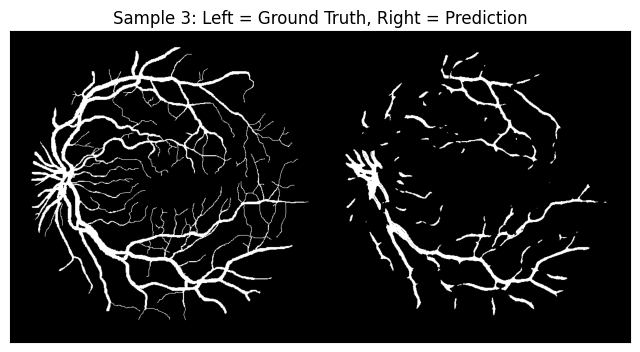

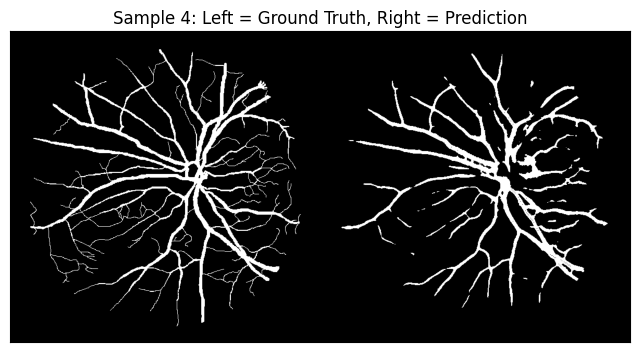

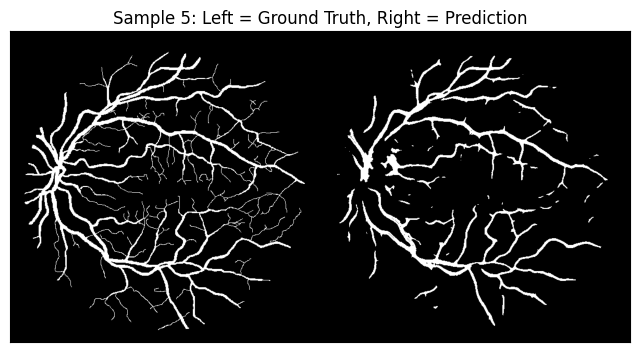

In [18]:
# ==================== Evaluation on Test Set ====================
# This cell evaluates the best model on the test set using accuracy, sensitivity, and Dice coefficient.

import torch
import torchvision
import matplotlib.pyplot as plt

# Load the best model (saved earlier) or reuse the model object
# If you have already trained a model and it's still in memory, you can use that.
# Otherwise, load the saved state dict:


# Define a function to compute all three metrics for a single batch
def compute_metrics(preds, labels):
    # Crop predictions back to original image size (using the global 'original_size' transform)
    preds_cropped = original_size(preds)
    labels_cropped = original_size(labels)
    
    # Binarize predictions (threshold=0.03)
    preds_bin = (preds_cropped > 0.5).float()
    
    # Compute metrics
    acc = accuracy(preds_bin, labels_cropped)
    sens = sensitivity(preds_bin, labels_cropped)
    dice = dice_coef(preds_bin, labels_cropped)
    return acc, sens, dice

# Initialize accumulators
total_acc = 0.0
total_sens = 0.0
total_dice = 0.0
num_samples = 0

# Evaluate on test set
with torch.no_grad():
    for inputs, inputs_LIOT_vp, labels in dataloaders['test']:
        inputs = inputs.to(device)
        inputs_LIOT_vp = inputs_LIOT_vp.to(device)
        labels = labels.to(device)
        
        outputs = model(inputs_LIOT_vp)
        outputs = torch.sigmoid(outputs)
        
        # Post-processing (same as in test_model)
        preds = outputs > 0.5
        preds = remove_circle(inputs, preds, 7, 0.1)
        
        acc, sens, dice = compute_metrics(preds, labels)
        total_acc += acc
        total_sens += sens
        total_dice += dice
        num_samples += 1

# Average metrics over test set
avg_acc = total_acc / num_samples
avg_sens = total_sens / num_samples
avg_dice = total_dice / num_samples

print(f"Test set results:")
print(f"Accuracy:  {avg_acc:.4f}")
print(f"Sensitivity: {avg_sens:.4f}")
print(f"Dice:      {avg_dice:.4f}")

# Optional: Visualize some predictions (as in the test_model function)
for i, (inputs, inputs_LIOT_vp, labels) in enumerate(dataloaders['test']):
    if i >= 5:  # show only first 5 images
        break
    inputs = inputs.to(device)
    inputs_LIOT_vp = inputs_LIOT_vp.to(device)
    labels = labels.to(device)
    
    outputs = model(inputs_LIOT_vp)
    outputs = torch.sigmoid(outputs)
    preds = outputs > 0.5
    preds = remove_circle(inputs, preds, 7, 0.1)
    
    grid = torchvision.utils.make_grid([labels[0], preds[0]]).cpu()
    plt.figure(figsize=(8,8))
    plt.imshow(grid.permute(1,2,0))
    plt.title(f"Sample {i+1}: Left = Ground Truth, Right = Prediction")
    plt.xticks([]); plt.yticks([])
    plt.show()

Test set results:
Accuracy:  0.9297
Sensitivity: 0.4803
Dice:      0.5430